####  Extend the model to Multiple Linear Regression using two or more input features and evaluate performance.

In [28]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

np.random.seed(42)

x1 = np.arange(0, 1, 0.02)
x2 = np.random.rand(len(x1))

# Combine into one matrix
X = np.column_stack((x1, x2))

# y = 5*x1 + 2*x2 + 3
noise = np.random.normal(0, 0.1, len(x1))
y = 5*x1 + 2*x2 + 3 + noise

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)
X_train, y_train = torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1)
X_test, y_test = torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1)

In [30]:
class MultipleLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(in_features=2,out_features=1)

    def forward(self, x):
        return self.linear(x)

In [31]:
torch.manual_seed(42)

model = MultipleLinearRegression()

In [32]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [33]:
epochs = 100
train_loss_list = []
test_loss_list = []

for epoch in range(epochs):

    # -------- TRAINING --------
    model.train()
    y_pred = model(X_train)
    train_loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # -------- TESTING --------
    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

    # Store losses
    train_loss_list.append(train_loss.item())
    test_loss_list.append(test_loss.item())

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}")

Epoch 1 | Train Loss: 38.000076 | Test Loss: 18.214331
Epoch 11 | Train Loss: 0.415033 | Test Loss: 0.312891
Epoch 21 | Train Loss: 0.277684 | Test Loss: 0.226088
Epoch 31 | Train Loss: 0.204705 | Test Loss: 0.166693
Epoch 41 | Train Loss: 0.152437 | Test Loss: 0.123798
Epoch 51 | Train Loss: 0.114771 | Test Loss: 0.092868
Epoch 61 | Train Loss: 0.087465 | Test Loss: 0.070472
Epoch 71 | Train Loss: 0.067546 | Test Loss: 0.054182
Epoch 81 | Train Loss: 0.052922 | Test Loss: 0.042279
Epoch 91 | Train Loss: 0.042116 | Test Loss: 0.033544


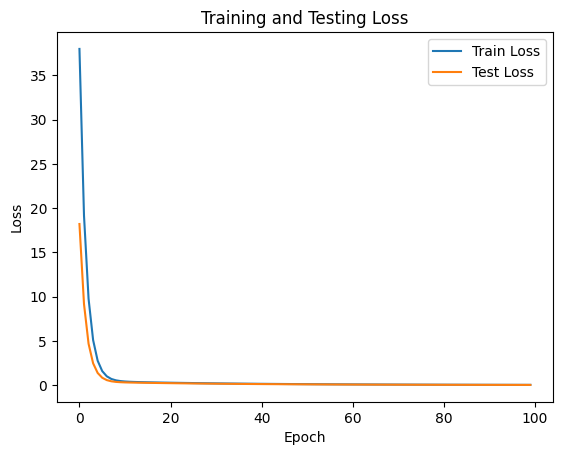

In [34]:
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.show()

In [35]:
print("Training Finished!")
print(f"Final Weight: {model.linear.weight}")
print(f"Final Bias: {model.linear.bias}")

Training Finished!
Final Weight: Parameter containing:
tensor([[4.4898, 1.8868]], requires_grad=True)
Final Bias: Parameter containing:
tensor([3.3278], requires_grad=True)


In [36]:
with torch.inference_mode():
    original_predictions = model(X_test)

In [37]:
print(original_predictions)

tensor([[4.8958],
        [7.6603],
        [7.1680],
        [8.6186],
        [5.8444],
        [8.6695],
        [6.0392],
        [7.0542],
        [6.3240],
        [5.5834],
        [5.9760],
        [3.9814],
        [6.8345],
        [5.1804],
        [4.7267]])


In [38]:
torch.save(model.state_dict(), "multiple_linear_model.pth")

In [39]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[4.4898, 1.8868]])),
             ('linear.bias', tensor([3.3278]))])